In [1]:
import re
import pandas as pd
import requests

In [3]:
BASE = "https://www.data.jma.go.jp/sakura/data/"
PAGES = [f"sakura003_0{n}.html" for n in range(1, 8)]  # 1961-2025
STATION = "東京"

In [6]:
def parse_pre(html):
    """<pre> 内の固定長テキストから東京の {年: (月, 日)} を抜き出す。"""
    pre = re.search(r"<pre[^>]*>(.*?)</pre>", html, re.S | re.I).group(1)
    pre = re.sub(r"<[^>]+>", "", pre)
    lines = pre.splitlines()
    header = next(l for l in lines if re.search(r"(19|20)\d\d", l))
    years = [int(y) for y in re.findall(r"(19\d\d|20\d\d)", header)]
    row = next(l for l in lines if l.startswith(STATION))
    tokens = row[len(STATION):].replace("*", " ").split()
    result, i, yi = {}, 0, 0
    pre = re.search(r"<pre[^>]*>(.*?)</pre>", html, re.S | re.I).group(1)
    pre = re.sub(r"<[^>]+>", "", pre)
    lines = pre.splitlines()
    header = next(l for l in lines if re.search(r"(19|20)\d\d", l))
    years = [int(y) for y in re.findall(r"(19\d\d|20\d\d)", header)]
    row = next(l for l in lines if l.startswith(STATION))
    tokens = row[len(STATION):].replace("*", " ").split()
    result, i, yi = {}, 0, 0
    while i < len(tokens) and yi < len(years):
        if tokens[i] == "-":
            result[years[yi]] = None
            i, yi = i + 1, yi + 1
        elif tokens[i].isdigit():
            result[years[yi]] = (int(tokens[i]), int(tokens[i + 1]))
            i, yi = i + 2, yi + 1
        else:
            i += 1
    return result

In [7]:
records = {}
for page in PAGES:
    r = requests.get(BASE + page, timeout=30)
    r.encoding = "utf-8"
    records.update(parse_pre(r.text))

rows = [
    {"year": y, "month": md[0], "day": md[1]}
    for y, md in sorted(records.items())
    if md is not None
]
df = pd.DataFrame(rows)

In [8]:
df["doy"] = pd.to_datetime(
    df["year"].astype(str)
    + "-" + df["month"].astype(str)
    + "-" + df["day"].astype(str)
).dt.dayofyear

df = df.dropna(subset=["doy"]).sort_values("year").reset_index(drop=True)

In [9]:
from scipy import stats

reg = stats.linregress(df["year"], df["doy"])
print(f"傾き = {reg.slope:.4f} 日/年")
print(f"p値 = {reg.pvalue:.2g}  r = {reg.rvalue:.3f}")

傾き = -0.1972 日/年
p値 = 2.5e-07  r = -0.589


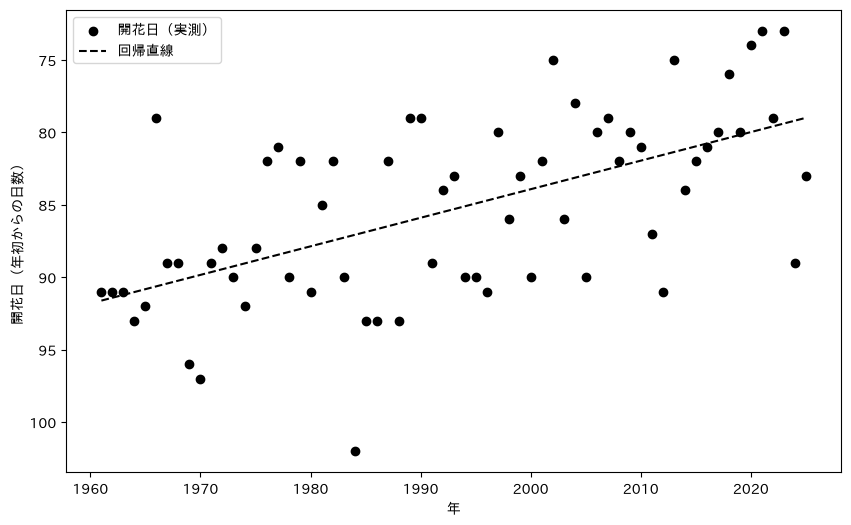

In [12]:
import matplotlib.pyplot as plt
import japanize_matplotlib

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["year"], df["doy"], label="開花日（実測）", color="black")
ax.plot(df["year"], reg.intercept + reg.slope * df["year"], label="回帰直線", color="black", linestyle="--")
ax.set_xlabel("年")
ax.set_ylabel("開花日（年初からの日数）")
ax.invert_yaxis()
ax.legend()